In [1]:
from load_data import load_raw_data
from clean_data import clean_data
from split_data import split_data
from evaluate_model import evaluate_model, view_ROC_curve, view_PR_curve
from config import RANDOM_STATE
from build_pipeline import objective,build_pipeline
from feature_engineering import build_new_features
import optuna
import logging

In [2]:
logging.basicConfig(
    level=logging.INFO,format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

In [3]:
# Loading raw data
dataset=load_raw_data()

2026-09-08 11:10:06,769 | INFO | load_data | Raw dataset loaded.


In [4]:
# Cleaning data
dataset_cleaned=clean_data(dataset)

2026-09-08 11:10:06,775 | INFO | clean_data | Dropped customerID.
2026-09-08 11:10:06,777 | INFO | clean_data | Converted TotalCharges to numeric.
2026-09-08 11:10:06,781 | INFO | clean_data | Rows containing NaN before cleaning: 11
2026-09-08 11:10:06,786 | INFO | clean_data | Removed 11 rows with invalid TotalCharges. Remaining rows with NaN: 0.


In [5]:
# Add new features
#dataset_cleaned=build_new_features(dataset_cleaned)

In [6]:
# Splitting data
X_train, X_test, y_train, y_test=split_data(dataset_cleaned, random_state=RANDOM_STATE)

2026-09-08 11:10:06,797 | INFO | split_data | Data split into train/test set with 0.8/0.2 proportion and random_state=0.


### XGBoost

In [7]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [8]:
# Creating optuna study for XGBoost
study_XGB = optuna.create_study(direction="maximize",sampler=sampler)

[I 2026-09-08 11:10:06,810] A new study created in memory with name: no-name-8037209d-2a27-45fe-8120-c45d6a1d66d9


In [9]:
# Optimizing optuna study for XGBoost
study_XGB.optimize(lambda trial: objective(trial, X_train, y_train, model='XGBoost'),n_trials=100)

[I 2026-09-08 11:10:08,379] Trial 0 finished with value: 0.6616995433674371 and parameters: {'xgb_learning_rate': 0.05939321535345923, 'xgb_max_depth': 5, 'xgb_min_child_weight': 16, 'xgb_subsample': 0.7634649548990691, 'xgb_colsample_bytree': 0.7270964398016714}. Best is trial 0 with value: 0.6616995433674371.
[I 2026-09-08 11:10:09,547] Trial 1 finished with value: 0.6655055017281386 and parameters: {'xgb_learning_rate': 0.06813047017599906, 'xgb_max_depth': 4, 'xgb_min_child_weight': 23, 'xgb_subsample': 0.8890988281503088, 'xgb_colsample_bytree': 0.7150324556477333}. Best is trial 1 with value: 0.6655055017281386.
[I 2026-09-08 11:10:10,715] Trial 2 finished with value: 0.6619408553493462 and parameters: {'xgb_learning_rate': 0.08125525342743982, 'xgb_max_depth': 4, 'xgb_min_child_weight': 16, 'xgb_subsample': 0.8776789914877983, 'xgb_colsample_bytree': 0.6213108174593661}. Best is trial 1 with value: 0.6655055017281386.
[I 2026-09-08 11:10:11,681] Trial 3 finished with value: 0.64

In [10]:
print("Best score for XGB:", study_XGB.best_value)
print("Best params for XGB:", study_XGB.best_params)

Best score for XGB: 0.6706272169090461
Best params for XGB: {'xgb_learning_rate': 0.08600390890027051, 'xgb_max_depth': 2, 'xgb_min_child_weight': 20, 'xgb_subsample': 0.6741562895950707, 'xgb_colsample_bytree': 0.7710770637865003}


In [11]:
# Fitting Logistic Regression pipeline with the best trial
pipe_XGB=build_pipeline(trial=study_XGB.best_trial, model= 'XGBoost')
fitted_pipe_XGB=pipe_XGB.fit(X_train, y_train)

### Logistic Regression

In [12]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [13]:
# Creating optuna study for Logistic Regression
study_LR = optuna.create_study(direction="maximize",sampler=sampler)

[I 2026-09-08 11:10:22,576] A new study created in memory with name: no-name-f9ad7927-f4b3-4876-baa2-24ada7ec2eb3


In [14]:
# Optimizing optuna study for Logistic Regression
study_LR.optimize(lambda trial: objective(trial, X_train, y_train, model='Logistic Regression'),n_trials=100)

[I 2026-09-08 11:10:22,702] Trial 0 finished with value: 0.6547439254743507 and parameters: {'lr_C': 0.15676677195506075, 'lr_penalty': 'l1'}. Best is trial 0 with value: 0.6547439254743507.
[I 2026-09-08 11:10:22,759] Trial 1 finished with value: 0.653640421576617 and parameters: {'lr_C': 0.15119336467641012, 'lr_penalty': 'l2'}. Best is trial 0 with value: 0.6547439254743507.
[I 2026-09-08 11:10:22,817] Trial 2 finished with value: 0.6526415633380159 and parameters: {'lr_C': 0.0562793204741517, 'lr_penalty': 'l2'}. Best is trial 0 with value: 0.6547439254743507.
[I 2026-09-08 11:10:22,883] Trial 3 finished with value: 0.6470174850789678 and parameters: {'lr_C': 0.03417952912061012, 'lr_penalty': 'l1'}. Best is trial 0 with value: 0.6547439254743507.
[I 2026-09-08 11:10:23,021] Trial 4 finished with value: 0.6547377083407683 and parameters: {'lr_C': 0.18714500686240676, 'lr_penalty': 'l1'}. Best is trial 0 with value: 0.6547439254743507.
[I 2026-09-08 11:10:23,078] Trial 5 finished wi

In [15]:
print("Best score for LR:", study_LR.best_value)
print("Best params for LR:", study_LR.best_params)

Best score for LR: 0.6553235138305386
Best params for LR: {'lr_C': 0.3301749725221848, 'lr_penalty': 'l1'}


In [16]:
# Fitting Logistic Regression pipeline with the best trial
pipe_LR=build_pipeline(trial=study_LR.best_trial, model= 'Logistic Regression')
fitted_pipe_LR=pipe_LR.fit(X_train, y_train)

### K-Nearest Neighbors

In [17]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [18]:
# Creating optuna study for K-Nearest Neighbors
study_KNN = optuna.create_study(direction="maximize",sampler=sampler)

[I 2026-09-08 11:10:40,495] A new study created in memory with name: no-name-0d8c823f-b1bc-4ff1-a02c-21050ca23c2d


In [19]:
# Optimizing optuna study for K-Nearest Neighbors
study_KNN.optimize(lambda trial: objective(trial, X_train, y_train, model='K-Nearest Neighbors'),n_trials=100)

[I 2026-09-08 11:10:40,604] Trial 0 finished with value: 0.6026407993392869 and parameters: {'knn_weights': 'distance', 'knn_n_neighbors': 32, 'knn_p': 2}. Best is trial 0 with value: 0.6026407993392869.
[I 2026-09-08 11:10:40,712] Trial 1 finished with value: 0.6015834630184523 and parameters: {'knn_weights': 'distance', 'knn_n_neighbors': 25, 'knn_p': 2}. Best is trial 0 with value: 0.6026407993392869.
[I 2026-09-08 11:10:40,819] Trial 2 finished with value: 0.6165942775502686 and parameters: {'knn_weights': 'uniform', 'knn_n_neighbors': 41, 'knn_p': 2}. Best is trial 2 with value: 0.6165942775502686.
[I 2026-09-08 11:10:41,017] Trial 3 finished with value: 0.5722329098920759 and parameters: {'knn_weights': 'distance', 'knn_n_neighbors': 8, 'knn_p': 1}. Best is trial 2 with value: 0.6165942775502686.
[I 2026-09-08 11:10:41,105] Trial 4 finished with value: 0.6056733143147912 and parameters: {'knn_weights': 'distance', 'knn_n_neighbors': 40, 'knn_p': 2}. Best is trial 2 with value: 0.

In [20]:
print("Best score for KNN:", study_KNN.best_value)
print("Best params for KNN:", study_KNN.best_params)

Best score for KNN: 0.6201628509707797
Best params for KNN: {'knn_weights': 'uniform', 'knn_n_neighbors': 50, 'knn_p': 1}


In [21]:
# Fitting K-Nearest Neighbors pipeline with the best trial
pipe_KNN=build_pipeline(trial=study_KNN.best_trial, model= 'K-Nearest Neighbors')
fitted_pipe_KNN=pipe_KNN.fit(X_train, y_train)

### Support Vector Machine

In [22]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [23]:
# Creating optuna study for Support Vector Machine
study_SVM = optuna.create_study(direction="maximize",sampler=sampler)

[I 2026-09-08 11:10:59,614] A new study created in memory with name: no-name-141e1e02-12c8-4cb4-9186-e044745ee852


In [24]:
# Optimizing optuna study for Support Vector Machine
study_SVM.optimize(lambda trial: objective(trial, X_train, y_train, model='Support Vector Machine'),n_trials=100)

[I 2026-09-08 11:11:02,792] Trial 0 finished with value: 0.6525529786679979 and parameters: {'svc_C': 0.44303752452182665, 'svc_gamma': 0.013981961408994055}. Best is trial 0 with value: 0.6525529786679979.
[I 2026-09-08 11:11:05,979] Trial 1 finished with value: 0.6521844893910715 and parameters: {'svc_C': 0.6431172050131991, 'svc_gamma': 0.004311710058685493}. Best is trial 0 with value: 0.6525529786679979.
[I 2026-09-08 11:11:09,265] Trial 2 finished with value: 0.6506510997547494 and parameters: {'svc_C': 0.18662266976517972, 'svc_gamma': 0.008663279761354562}. Best is trial 0 with value: 0.6525529786679979.
[I 2026-09-08 11:11:12,371] Trial 3 finished with value: 0.6395498587910559 and parameters: {'svc_C': 0.20547625125911342, 'svc_gamma': 0.04734989304499478}. Best is trial 0 with value: 0.6525529786679979.
[I 2026-09-08 11:11:15,420] Trial 4 finished with value: 0.6533982983547629 and parameters: {'svc_C': 7.780155576901417, 'svc_gamma': 0.0014135935551752314}. Best is trial 4 

In [25]:
print("Best score for SVM:", study_SVM.best_value)
print("Best params for SVM:", study_SVM.best_params)

Best score for SVM: 0.6544456005940881
Best params for SVM: {'svc_C': 4.194166003954934, 'svc_gamma': 0.0029897173892248705}


In [26]:
# Fitting Support Vector Machine pipeline with the best trial
pipe_SVM=build_pipeline(trial=study_SVM.best_trial, model= 'Support Vector Machine')
fitted_pipe_SVM=pipe_SVM.fit(X_train, y_train)

### Decision Tree

In [27]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [28]:
# Creating optuna study for Decision Tree
study_DT = optuna.create_study(direction="maximize",sampler=sampler)

[I 2026-09-08 11:16:36,811] A new study created in memory with name: no-name-460d7bf8-b4fe-43bd-8ace-2997d746bd2a


In [29]:
# Optimizing optuna study for Decision Tree
study_DT.optimize(lambda trial: objective(trial, X_train, y_train, model='Decision Tree'),n_trials=100)

[I 2026-09-08 11:16:36,878] Trial 0 finished with value: 0.6053575119691368 and parameters: {'dt_max_depth': 5, 'dt_min_samples_split': 39, 'dt_min_samples_leaf': 26}. Best is trial 0 with value: 0.6053575119691368.
[I 2026-09-08 11:16:36,955] Trial 1 finished with value: 0.6053573666030204 and parameters: {'dt_max_depth': 5, 'dt_min_samples_split': 27, 'dt_min_samples_leaf': 28}. Best is trial 0 with value: 0.6053575119691368.
[I 2026-09-08 11:16:37,022] Trial 2 finished with value: 0.6055996499214962 and parameters: {'dt_max_depth': 5, 'dt_min_samples_split': 46, 'dt_min_samples_leaf': 39}. Best is trial 2 with value: 0.6055996499214962.
[I 2026-09-08 11:16:37,079] Trial 3 finished with value: 0.58896181710313 and parameters: {'dt_max_depth': 4, 'dt_min_samples_split': 42, 'dt_min_samples_leaf': 24}. Best is trial 2 with value: 0.6055996499214962.
[I 2026-09-08 11:16:37,147] Trial 4 finished with value: 0.6062535713748417 and parameters: {'dt_max_depth': 5, 'dt_min_samples_split': 47

In [30]:
print("Best score for DT:", study_DT.best_value)
print("Best params for DT:", study_DT.best_params)

Best score for DT: 0.6202765529471577
Best params for DT: {'dt_max_depth': 7, 'dt_min_samples_split': 30, 'dt_min_samples_leaf': 29}


In [31]:
# Fitting Decision Tree pipeline with the best trial
pipe_DT=build_pipeline(trial=study_DT.best_trial, model= 'Decision Tree')
fitted_pipe_DT=pipe_DT.fit(X_train, y_train)

### Random Forest

In [32]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

In [33]:
# Creating optuna study for Random Forest
study_RF = optuna.create_study(direction="maximize",sampler=sampler)

[I 2026-09-08 11:16:43,859] A new study created in memory with name: no-name-15043478-e79e-4787-ad82-db4ce855fb94


In [34]:
# Optimizing optuna study for Random Forest
study_RF.optimize(lambda trial: objective(trial, X_train, y_train, model='Random Forest'),n_trials=100)

[I 2026-09-08 11:16:44,442] Trial 0 finished with value: 0.6601692919795586 and parameters: {'rf_max_depth': 7, 'rf_min_samples_leaf': 15, 'rf_max_features': 'sqrt'}. Best is trial 0 with value: 0.6601692919795586.
[I 2026-09-08 11:16:44,995] Trial 1 finished with value: 0.6616358599619038 and parameters: {'rf_max_depth': 8, 'rf_min_samples_leaf': 10, 'rf_max_features': 'log2'}. Best is trial 1 with value: 0.6616358599619038.
[I 2026-09-08 11:16:45,558] Trial 2 finished with value: 0.6609544194210897 and parameters: {'rf_max_depth': 9, 'rf_min_samples_leaf': 12, 'rf_max_features': 'log2'}. Best is trial 1 with value: 0.6616358599619038.
[I 2026-09-08 11:16:46,655] Trial 3 finished with value: 0.632617718376318 and parameters: {'rf_max_depth': 3, 'rf_min_samples_leaf': 2, 'rf_max_features': None}. Best is trial 1 with value: 0.6616358599619038.
[I 2026-09-08 11:16:47,197] Trial 4 finished with value: 0.6616737386529239 and parameters: {'rf_max_depth': 10, 'rf_min_samples_leaf': 17, 'rf_

In [35]:
print("Best score for RF:", study_RF.best_value)
print("Best params for RF:", study_RF.best_params)

Best score for RF: 0.6626808948806134
Best params for RF: {'rf_max_depth': 8, 'rf_min_samples_leaf': 17, 'rf_max_features': 'sqrt'}


In [36]:
# Fitting Random Forest pipeline with the best trial
pipe_RF=build_pipeline(trial=study_RF.best_trial, model= 'Random Forest')
fitted_pipe_RF=pipe_RF.fit(X_train, y_train)

### Model performances

In [37]:
metrics_XGB,report_XGB=evaluate_model(fitted_pipe_XGB,X_test,y_test,threshold=0.5)
metrics_XGB

2026-09-08 11:17:56,166 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for XGBClassifier classification model (Threshold: 0.5).


{'classifier_name': 'XGBClassifier',
 'threshold': 0.5,
 'accuracy': 0.751,
 'f1': 0.627,
 'f2': 0.715,
 'precision': 0.52,
 'recall': 0.789,
 'roc_auc': 0.854,
 'average_precision': 0.672,
 'confusion_matrix': [[761, 272], [79, 295]]}

In [38]:
metrics_LR,report_LR=evaluate_model(fitted_pipe_LR,X_test,y_test,threshold=0.5)
metrics_LR

2026-09-08 11:17:56,191 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for LogisticRegression classification model (Threshold: 0.5).


{'classifier_name': 'LogisticRegression',
 'threshold': 0.5,
 'accuracy': 0.753,
 'f1': 0.631,
 'f2': 0.719,
 'precision': 0.523,
 'recall': 0.794,
 'roc_auc': 0.851,
 'average_precision': 0.659,
 'confusion_matrix': [[762, 271], [77, 297]]}

In [39]:
metrics_KNN,report_KNN=evaluate_model(fitted_pipe_KNN,X_test,y_test,threshold=0.5)
metrics_KNN

2026-09-08 11:17:56,286 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for KNeighborsClassifier classification model (Threshold: 0.5).


{'classifier_name': 'KNeighborsClassifier',
 'threshold': 0.5,
 'accuracy': 0.805,
 'f1': 0.628,
 'f2': 0.623,
 'precision': 0.636,
 'recall': 0.62,
 'roc_auc': 0.847,
 'average_precision': 0.64,
 'confusion_matrix': [[900, 133], [142, 232]]}

In [40]:
metrics_SVM,report_SVM=evaluate_model(fitted_pipe_SVM,X_test,y_test,threshold=0.5)
metrics_SVM

2026-09-08 11:17:56,491 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for SVC classification model (Threshold: 0.5).


{'classifier_name': 'SVC',
 'threshold': 0.5,
 'accuracy': 0.803,
 'f1': 0.618,
 'f2': 0.606,
 'precision': 0.638,
 'recall': 0.599,
 'roc_auc': 0.844,
 'average_precision': 0.652,
 'confusion_matrix': [[906, 127], [150, 224]]}

In [41]:
metrics_DT,report_DT=evaluate_model(fitted_pipe_DT,X_test,y_test,threshold=0.5)
metrics_DT

2026-09-08 11:17:56,520 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for DecisionTreeClassifier classification model (Threshold: 0.5).


{'classifier_name': 'DecisionTreeClassifier',
 'threshold': 0.5,
 'accuracy': 0.738,
 'f1': 0.616,
 'f2': 0.711,
 'precision': 0.504,
 'recall': 0.791,
 'roc_auc': 0.827,
 'average_precision': 0.635,
 'confusion_matrix': [[742, 291], [78, 296]]}

In [42]:
metrics_RF,report_RF=evaluate_model(fitted_pipe_RF,X_test,y_test,threshold=0.5)
metrics_RF

2026-09-08 11:17:56,560 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for RandomForestClassifier classification model (Threshold: 0.5).


{'classifier_name': 'RandomForestClassifier',
 'threshold': 0.5,
 'accuracy': 0.752,
 'f1': 0.624,
 'f2': 0.705,
 'precision': 0.523,
 'recall': 0.773,
 'roc_auc': 0.852,
 'average_precision': 0.663,
 'confusion_matrix': [[769, 264], [85, 289]]}

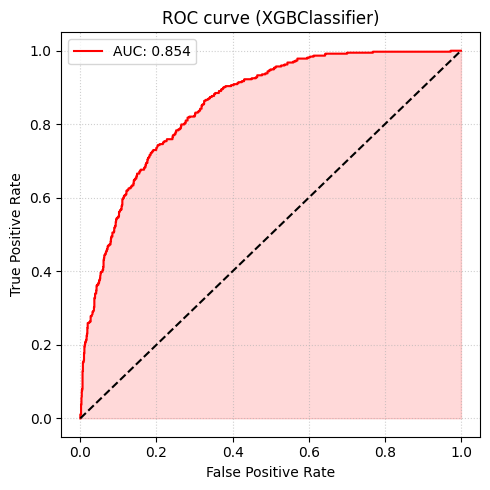

2026-09-08 11:17:56,704 | INFO | evaluate_model | ROC Curve and AUC for XGBClassifier classification model.


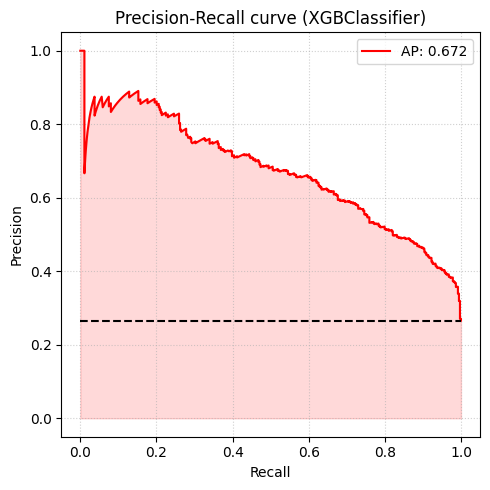

2026-09-08 11:17:56,902 | INFO | evaluate_model | Precision-Recall Curve for XGBClassifier classification model.


In [43]:
_,_=view_ROC_curve(fitted_pipe_XGB,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_XGB,X_test,y_test)

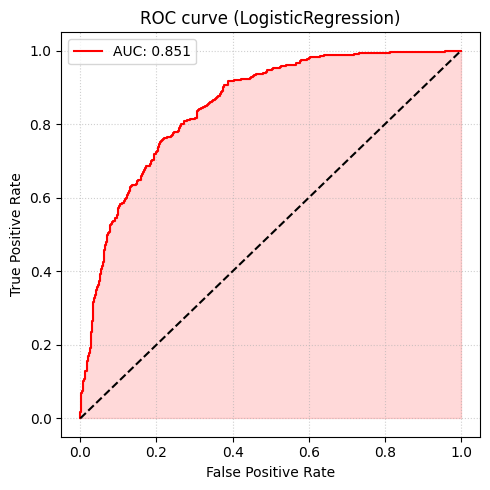

2026-09-08 11:17:57,027 | INFO | evaluate_model | ROC Curve and AUC for LogisticRegression classification model.


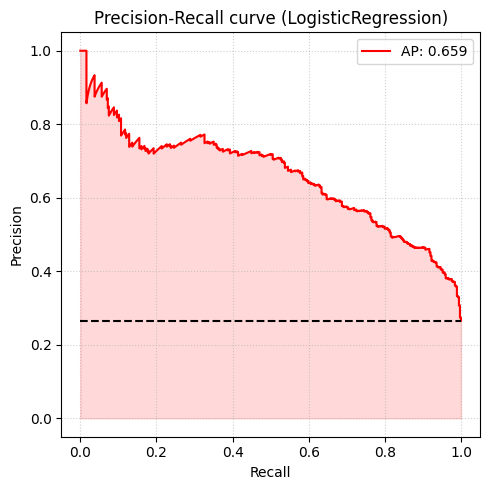

2026-09-08 11:17:57,118 | INFO | evaluate_model | Precision-Recall Curve for LogisticRegression classification model.


In [44]:
_,_=view_ROC_curve(fitted_pipe_LR,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_LR,X_test,y_test)

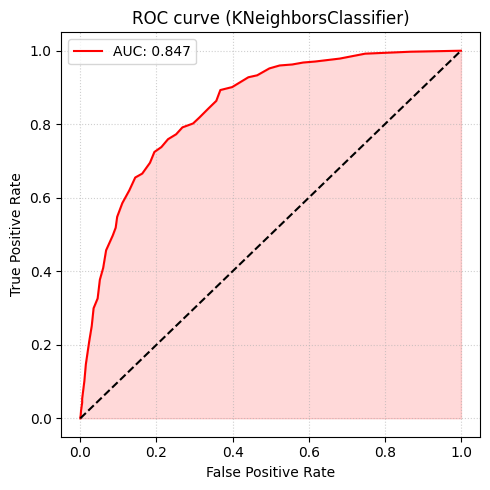

2026-09-08 11:17:57,261 | INFO | evaluate_model | ROC Curve and AUC for KNeighborsClassifier classification model.


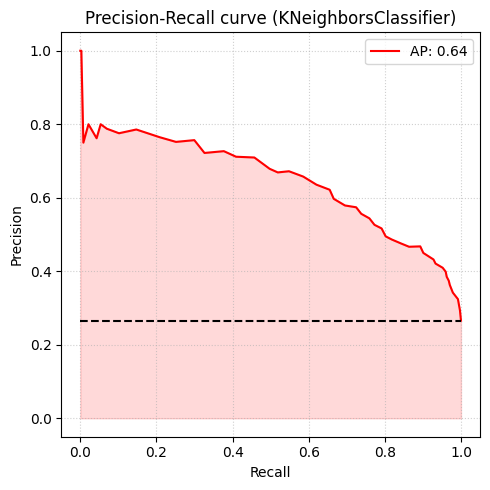

2026-09-08 11:17:57,393 | INFO | evaluate_model | Precision-Recall Curve for KNeighborsClassifier classification model.


In [45]:
_,_=view_ROC_curve(fitted_pipe_KNN,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_KNN,X_test,y_test)

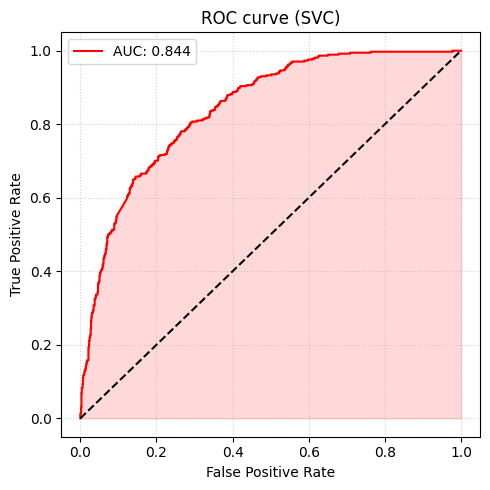

2026-09-08 11:17:57,656 | INFO | evaluate_model | ROC Curve and AUC for SVC classification model.


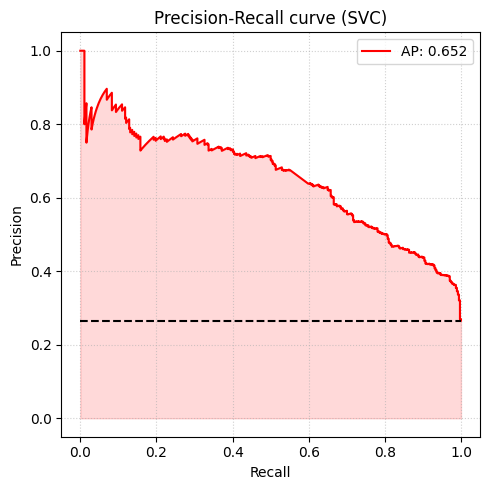

2026-09-08 11:17:57,909 | INFO | evaluate_model | Precision-Recall Curve for SVC classification model.


In [46]:
_,_=view_ROC_curve(fitted_pipe_SVM,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_SVM,X_test,y_test)

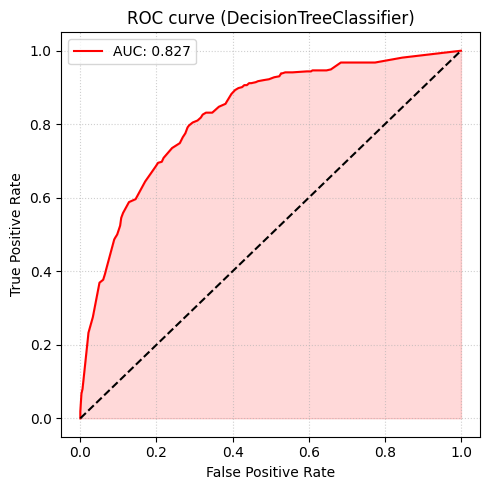

2026-09-08 11:17:58,009 | INFO | evaluate_model | ROC Curve and AUC for DecisionTreeClassifier classification model.


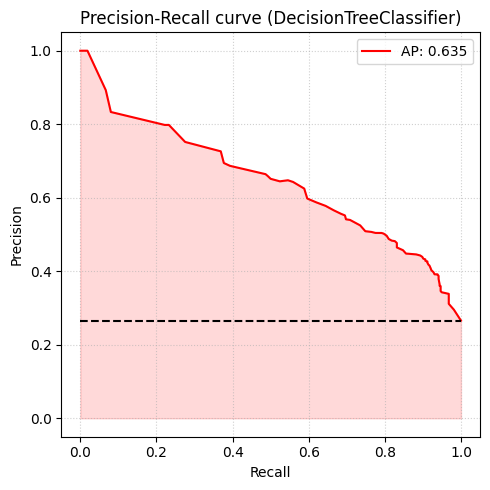

2026-09-08 11:17:58,099 | INFO | evaluate_model | Precision-Recall Curve for DecisionTreeClassifier classification model.


In [47]:
_,_=view_ROC_curve(fitted_pipe_DT,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_DT,X_test,y_test)

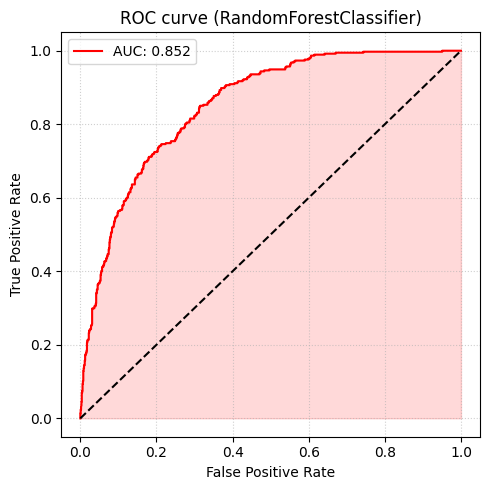

2026-09-08 11:17:58,216 | INFO | evaluate_model | ROC Curve and AUC for RandomForestClassifier classification model.


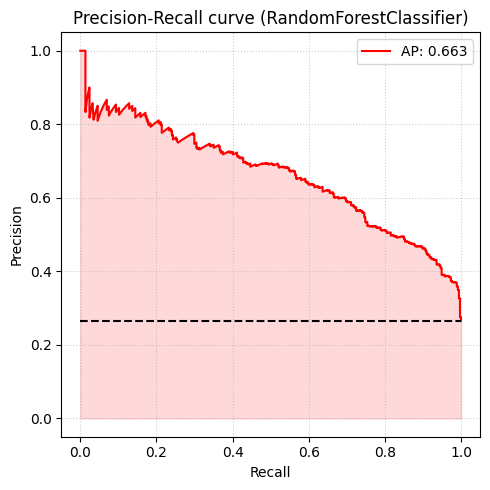

2026-09-08 11:17:58,327 | INFO | evaluate_model | Precision-Recall Curve for RandomForestClassifier classification model.


In [48]:
_,_=view_ROC_curve(fitted_pipe_RF,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_RF,X_test,y_test)

### Quick comparison of LR and XGBoost errors

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
pd.crosstab(fitted_pipe_XGB.predict(X_test),fitted_pipe_LR.predict(X_test))

col_0,0,1
row_0,,
0,796,44
1,43,524


In [51]:
(43+44)/(796+524+43+44)

0.06183368869936034

In [52]:
#6.2% de discordância

In [53]:
y_pred_LR=fitted_pipe_LR.predict(X_test)
y_proba_LR=fitted_pipe_LR.predict_proba(X_test)[:,1]
y_pred_XGB=fitted_pipe_XGB.predict(X_test)
y_proba_XGB=fitted_pipe_XGB.predict_proba(X_test)[:,1]
index=[]
for j in range(len(X_test)):
    if y_pred_LR[j]!=y_pred_XGB[j]:
        index.append(j)
    else:
        pass

In [54]:
df_proba=pd.DataFrame((y_proba_LR,y_proba_XGB)).T.rename(columns={0:"LR",1:"XGB"})

In [55]:
df_dif=df_proba.iloc[index].copy()
df_dif.head()

,LR,XGB
10,0.535045,0.461880
12,0.513488,0.472478
14,0.508964,0.490808
16,0.623252,0.364248
18,0.490884,0.628277


In [56]:
df_dif["difference"]=df_dif["LR"]-df_dif["XGB"]

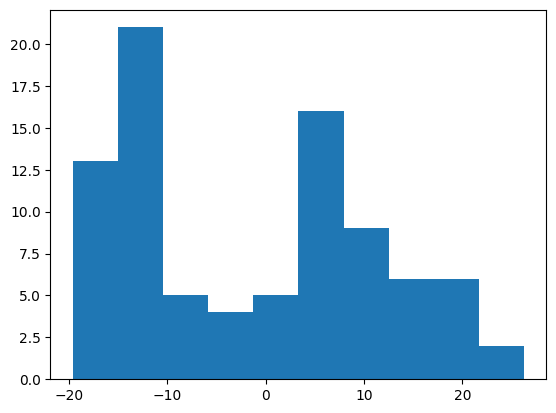

In [57]:
plt.hist(df_dif["difference"].values*100);

In [58]:
df_dif["difference"].mean()

np.float64(-0.011989178273363566)

In [59]:
df_dif["difference"].median()

np.float64(0.018155929260607273)

In [60]:
df_dif["difference"].std()

np.float64(0.12813044798157902)